# Assignment 8: Classification Task - Decision Tree

**Course Outcome**: CO3  
**Topic**: Loan Approval Classifier, Decision Tree Structure Visualization & Feature Importance  

### Objectives:
1. Build a Loan Approval Decision Tree Classifier.
2. Visualize the resulting decision tree structure.
3. Identify and explain the top 3 features the tree relies on most from a financial lending perspective.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print('Setup initialized successfully!')

Setup initialized successfully!


## 1. Load Loan Application Dataset
We inspect the lending dataset containing 600 records with financial indicators.

In [2]:
df = pd.read_csv('loan_data.csv')
print(f'Dataset Shape: {df.shape}')
df.head()

Dataset Shape: (600, 7)


,Credit_Score,Annual_Income,Debt_to_Income_Ratio,Loan_Amount,Employment_Years,Existing_Defaults,Loan_Approved
0,707,34322,0.602,52528,16.7,0,0
1,660,90457,0.275,49510,7.7,1,0
2,719,90020,0.050,6218,2.1,1,1
3,784,76366,0.180,59658,9.2,0,1
4,652,85120,0.355,29265,6.3,0,1


## 2. Train Decision Tree Classifier
We split into train/test sets (75/25) and fit an interpretable tree with `max_depth=3`.

In [3]:
feature_cols = ['Credit_Score', 'Annual_Income', 'Debt_to_Income_Ratio', 'Loan_Amount', 'Employment_Years', 'Existing_Defaults']
X = df[feature_cols]
y = df['Loan_Approved']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

dt = DecisionTreeClassifier(max_depth=3, criterion='gini', min_samples_leaf=15, random_state=42)
dt.fit(X_train, y_train)
print('Decision Tree trained successfully!')

Decision Tree trained successfully!


## 3. Evaluation on Test Set
We compute Accuracy, Precision, Recall, and the Confusion Matrix.

In [4]:
y_pred = dt.predict(X_test)
print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred):.4f}')
print(f'F1-Score : {f1_score(y_test, y_pred):.4f}')
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))

Accuracy : 0.8333
Precision: 0.8120
Recall   : 0.9694
F1-Score : 0.8837

Confusion Matrix:
 [[30 22]
 [ 3 95]]


## 4. Visualizing the Decision Tree
We plot the entire decision tree hierarchy, displaying splits, Gini impurity, sample proportions, and dominant class.

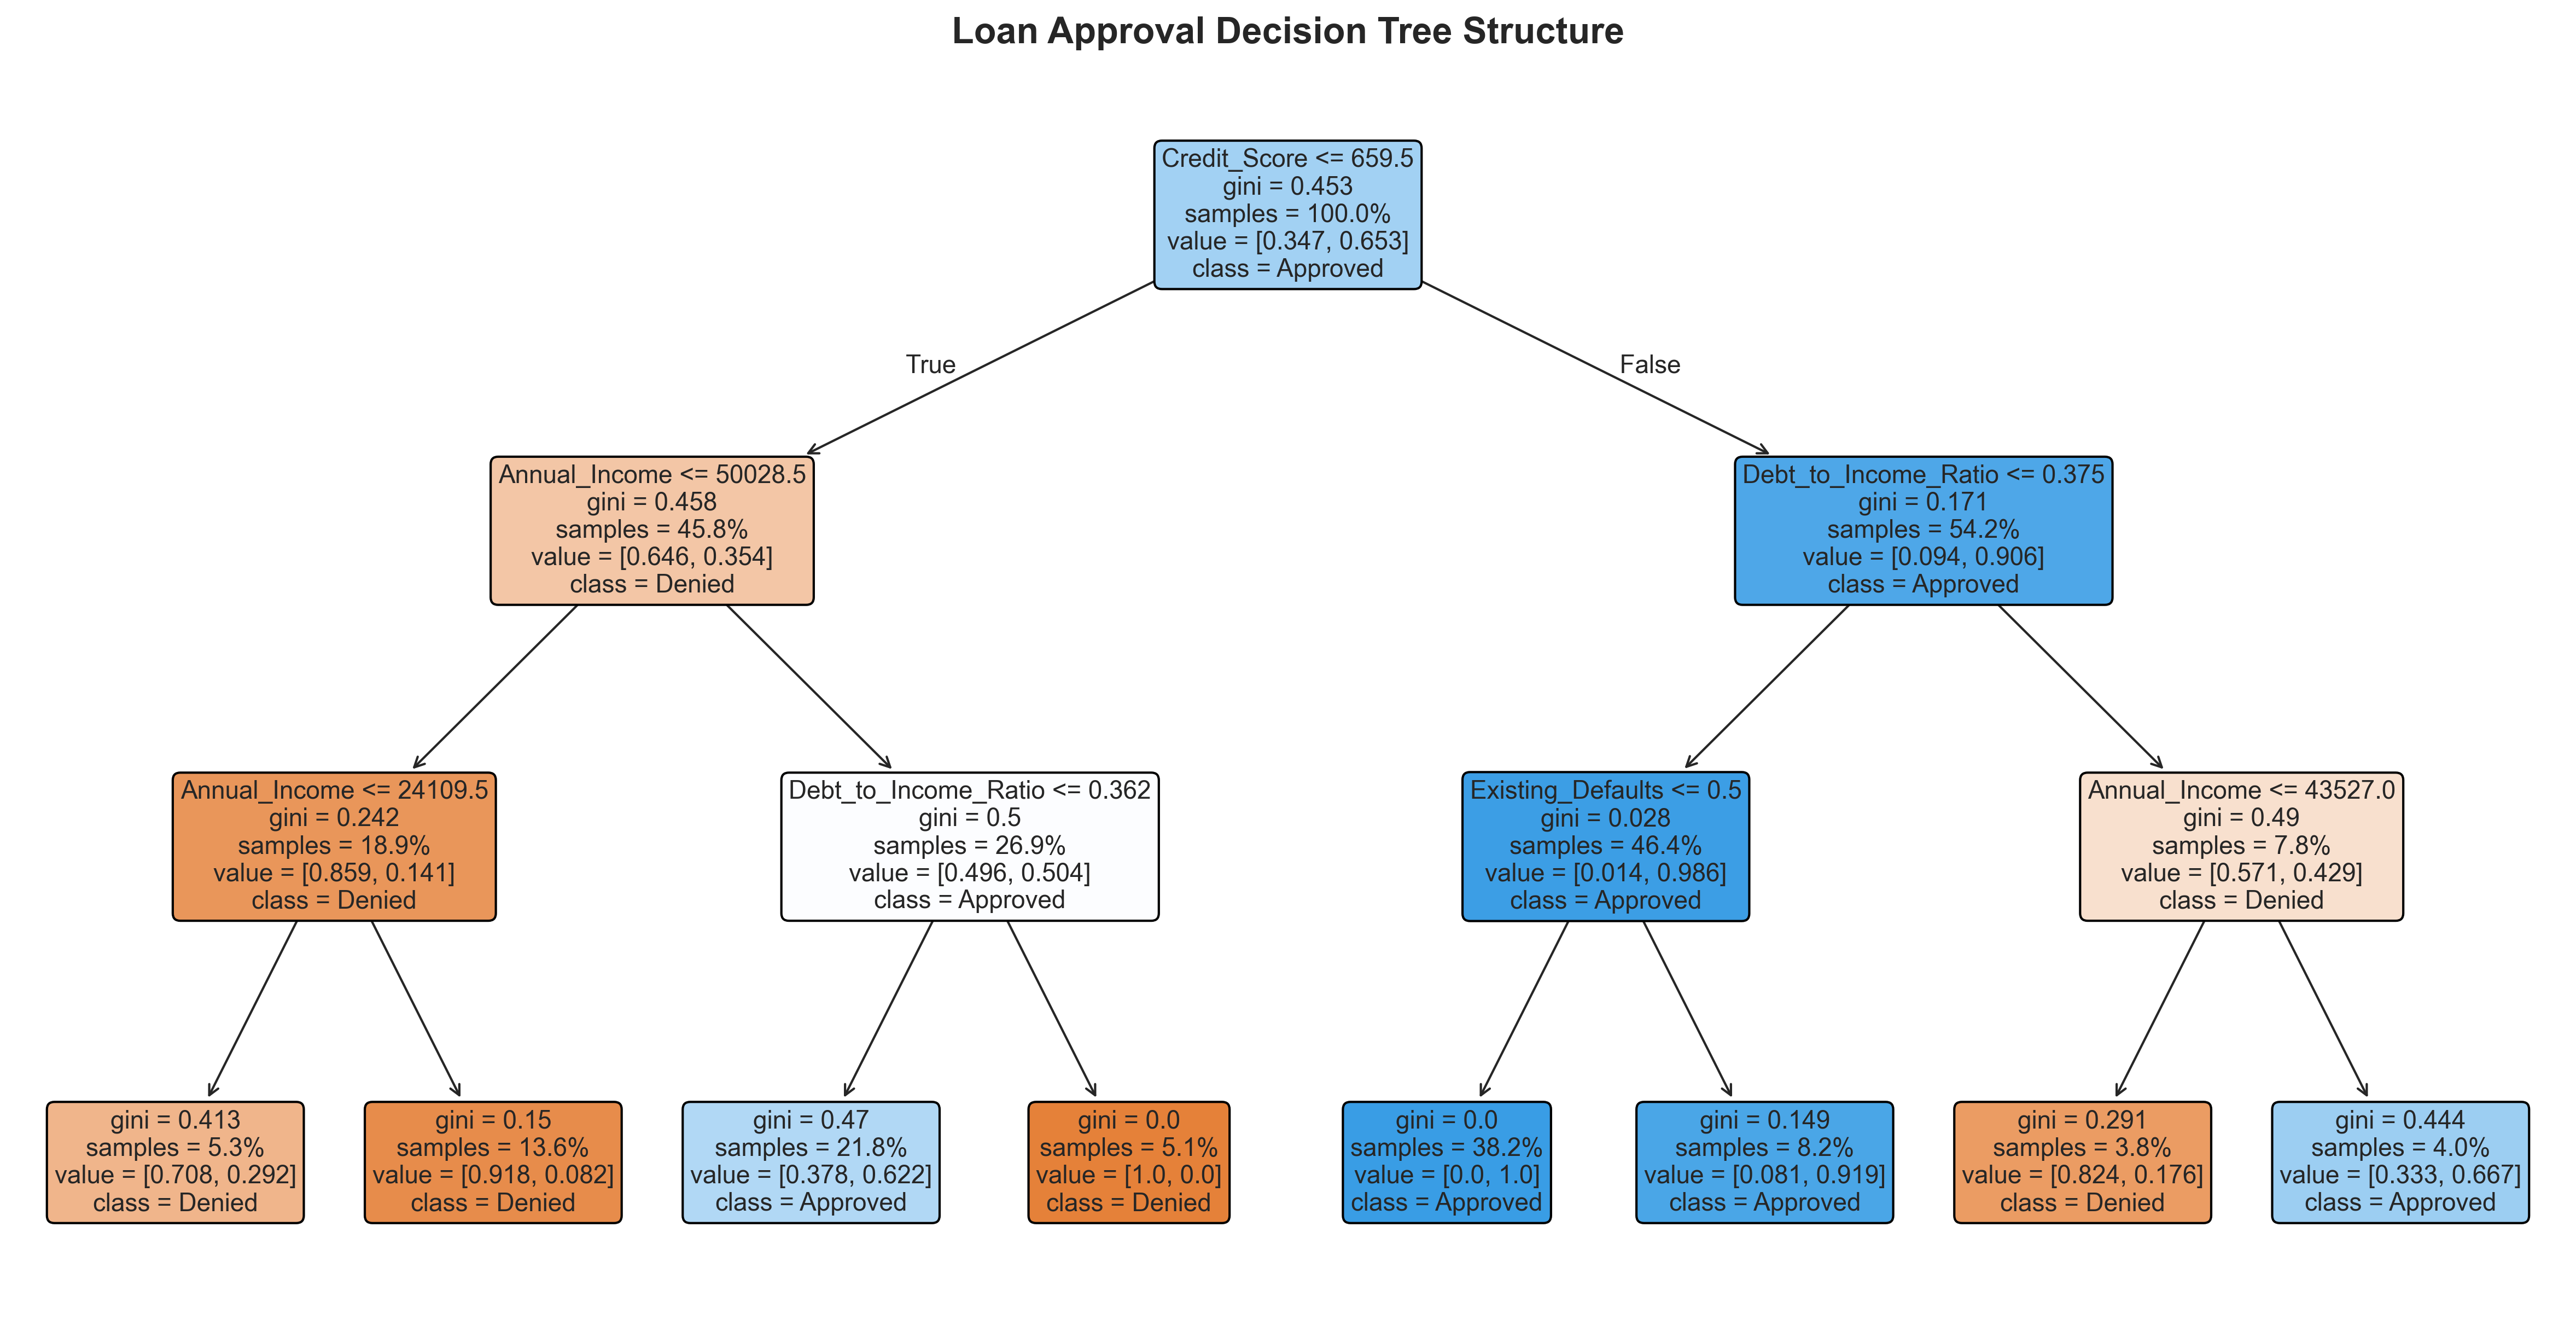

In [5]:
plt.figure(figsize=(20, 10), dpi=300)
plot_tree(
    dt,
    feature_names=feature_cols,
    class_names=['Denied', 'Approved'],
    filled=True,
    rounded=True,
    fontsize=11,
    proportion=True
)
plt.title('Loan Approval Decision Tree Structure', fontsize=16, fontweight='bold')
plt.show()

## 5. Identifying Top Features (Feature Importances)
We extract the Gini impurity reduction attributed to each feature.

=== Feature Importances ===
             Feature  Importance
        Credit_Score    0.564880
Debt_to_Income_Ratio    0.274829
       Annual_Income    0.156961
   Existing_Defaults    0.003330
         Loan_Amount    0.000000
    Employment_Years    0.000000


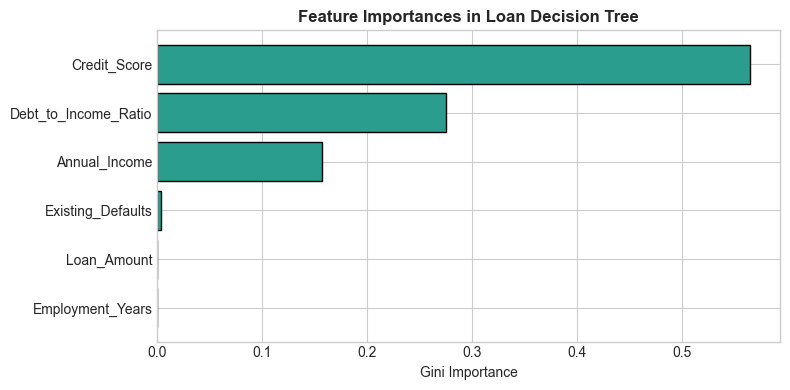

In [6]:
feat_imp = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=False)

print('=== Feature Importances ===')
print(feat_imp.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.barh(feat_imp['Feature'][::-1], feat_imp['Importance'][::-1], color='#2a9d8f', edgecolor='black')
plt.xlabel('Gini Importance')
plt.title('Feature Importances in Loan Decision Tree', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Financial Interpretation of Top Features

### Top 3 Features Identified:
1. **Credit Score**: Explains the single largest reduction in Gini impurity. In banking, credit score is the primary summary statistic of past repayment reliability and creditworthiness.
2. **Debt-to-Income (DTI) Ratio**: Serves as the second most critical split. A candidate with high income can still default if current debt obligations consume too much monthly cash flow.
3. **Existing Defaults / Annual Income**: Prior default history acts as an immediate red flag, while Annual Income confirms baseline cash generation capacity.

### Decision Path Reasoning:
- Applicants with high credit scores ($>660$) and low DTI ($\le 36\%$) are routed to high-purity 'Approved' leaves.
- Subprime applicants with low credit scores or high DTI are filtered out immediately at upper decision nodes, mirroring standard credit risk triage.